In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
credit_data = pd.read_csv(r"C:\Users\8341s\Documents\ML Specialization\Model Development\CardSecure\data\credit_data_eda.csv")

In [3]:
credit_data.head()

,id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,target,age_group,cumulative_bill,average_bill,credit_limit_group,credit_utilization,average_payment,payment_ratio,payment_ratio_1,payment_ratio_2,payment_ratio_3,payment_ratio_4,payment_ratio_5,payment_ratio_6,avg_payment_ratio
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,20s,7704,1284.000000,≤50K,0.064200,114.833333,0.089434,0.000000,0.222115,0.000000,NaN,NaN,NaN,0.074038
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,20s,17077,2846.166667,100K–200K,0.023718,833.333333,0.292791,0.000000,0.579710,0.372856,0.305623,0.000000,0.613309,0.311916
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,30s,101653,16942.166667,50K–100K,0.188246,1836.333333,0.108388,0.051917,0.106937,0.073752,0.069779,0.066899,0.321564,0.115141
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,30s,231334,38555.666667,≤50K,0.771113,1398.000000,0.036259,0.042562,0.041859,0.024345,0.038850,0.036914,0.033844,0.036396
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,50s,109339,18223.166667,≤50K,0.364463,9841.500000,0.540054,0.232099,6.469312,0.279057,0.429799,0.035987,0.035492,1.246958


In [4]:
credit_data = credit_data.drop(columns=[
    "id",
    "payment_ratio",
    "payment_ratio_1",
    "payment_ratio_2",
    "payment_ratio_3",
    "payment_ratio_4",
    "payment_ratio_5",
    "payment_ratio_6",
    "cumulative_bill"
])

In [5]:
credit_data.head()

,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,target,age_group,average_bill,credit_limit_group,credit_utilization,average_payment,avg_payment_ratio
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,20s,1284.000000,≤50K,0.064200,114.833333,0.074038
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,20s,2846.166667,100K–200K,0.023718,833.333333,0.311916
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,30s,16942.166667,50K–100K,0.188246,1836.333333,0.115141
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,30s,38555.666667,≤50K,0.771113,1398.000000,0.036396
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,50s,18223.166667,≤50K,0.364463,9841.500000,1.246958


### Feature Engineering

##### Question: Is the customer's outstanding balance increasing or decreasing over time?
##### Positive values indicate bills have increased from April to September.

In [6]:
for i in range(1, 6):
    credit_data[f"bill_trend_{i}"] = (
        credit_data[f"bill_amt{i}"] - credit_data[f"bill_amt{i+1}"]
    )

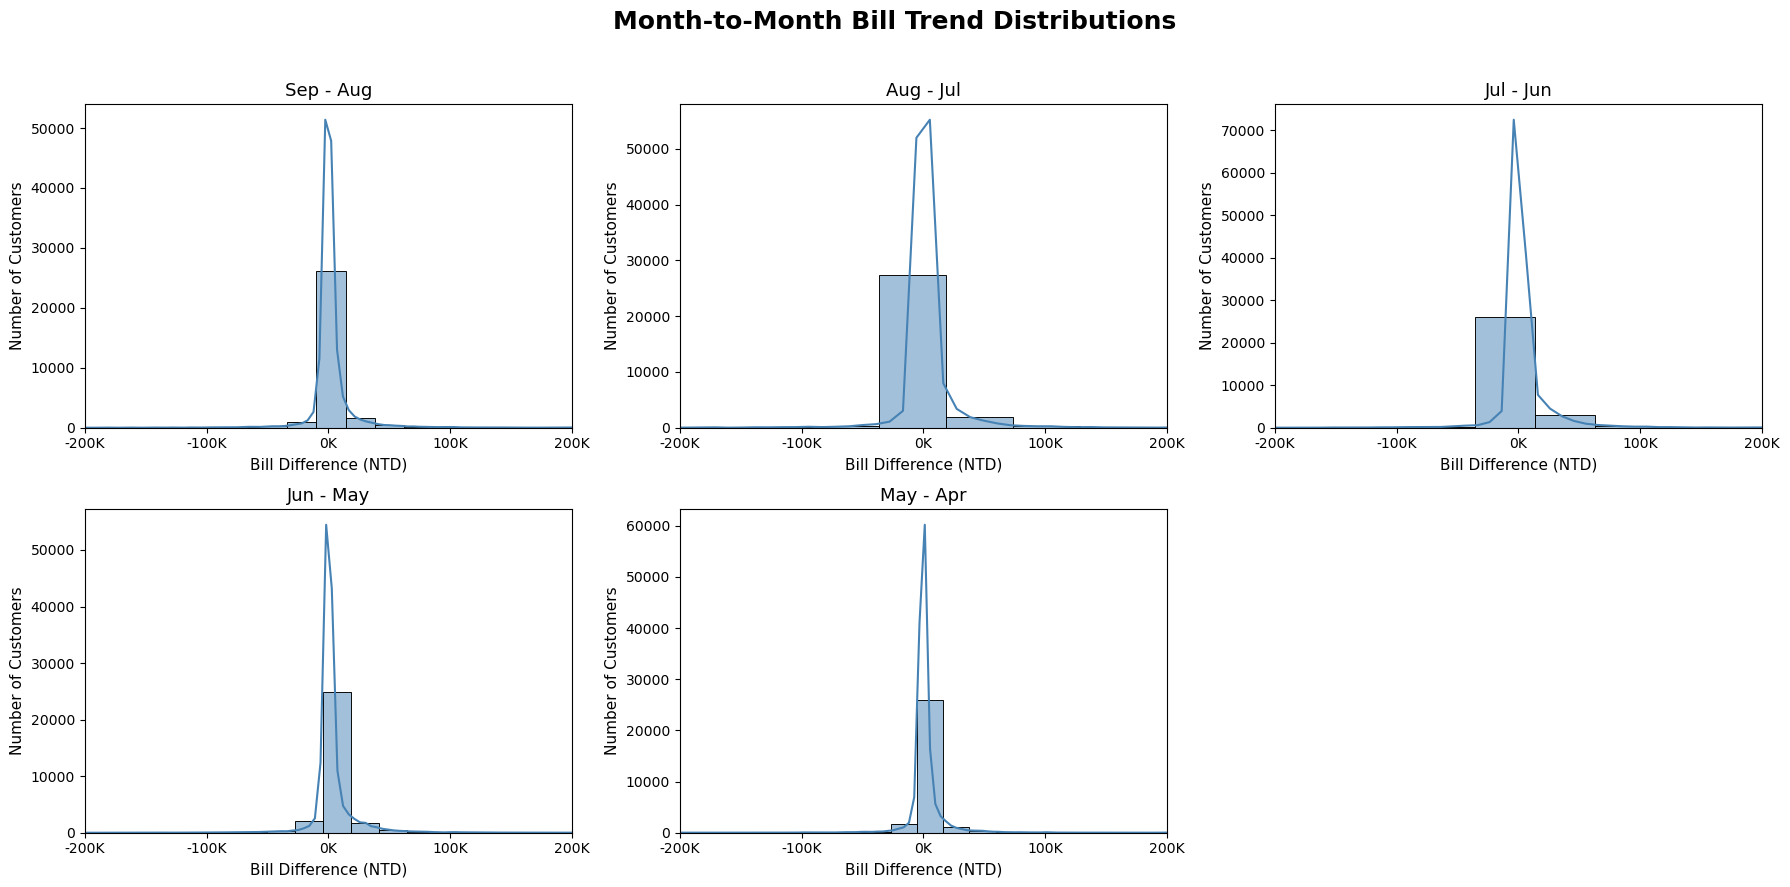

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Month-to-month bill trend columns
trend_cols = [f"bill_trend_{i}" for i in range(1, 6)]

titles = [
    "Sep - Aug",
    "Aug - Jul",
    "Jul - Jun",
    "Jun - May",
    "May - Apr"
]

# Formatter to display values in thousands (K)
formatter = FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col, title in zip(axes.flatten(), trend_cols, titles):

    sns.histplot(
        data=credit_data,
        x=col,
        bins=40,
        kde=True,
        ax=ax,
        color="steelblue"
    )

    # Same scale for all plots
    ax.set_xlim(-200000, 200000)

    # Fixed tick locations
    ax.set_xticks([-200000, -100000, 0, 100000, 200000])

    # Display in thousands
    ax.xaxis.set_major_formatter(formatter)

    # Rotate labels
    # ax.tick_params(axis="x", rotation=45)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Bill Difference (NTD)", fontsize=11)
    ax.set_ylabel("Number of Customers", fontsize=11)

# Hide the unused subplot
axes[1, 2].axis("off")

plt.suptitle(
    "Month-to-Month Bill Trend Distributions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Payment Trend

##### Payment Trend is the month-to-month change in the amount paid by a customer toward their credit card bill. It measures whether a customer's 
##### repayment amount has increased, decreased, or remained stable between two consecutive billing cycles.

In [8]:
for i in range(1, 6):
    credit_data[f"payment_trend_{i}"] = (
        credit_data[f"pay_amt{i}"] - credit_data[f"pay_amt{i+1}"]
    )

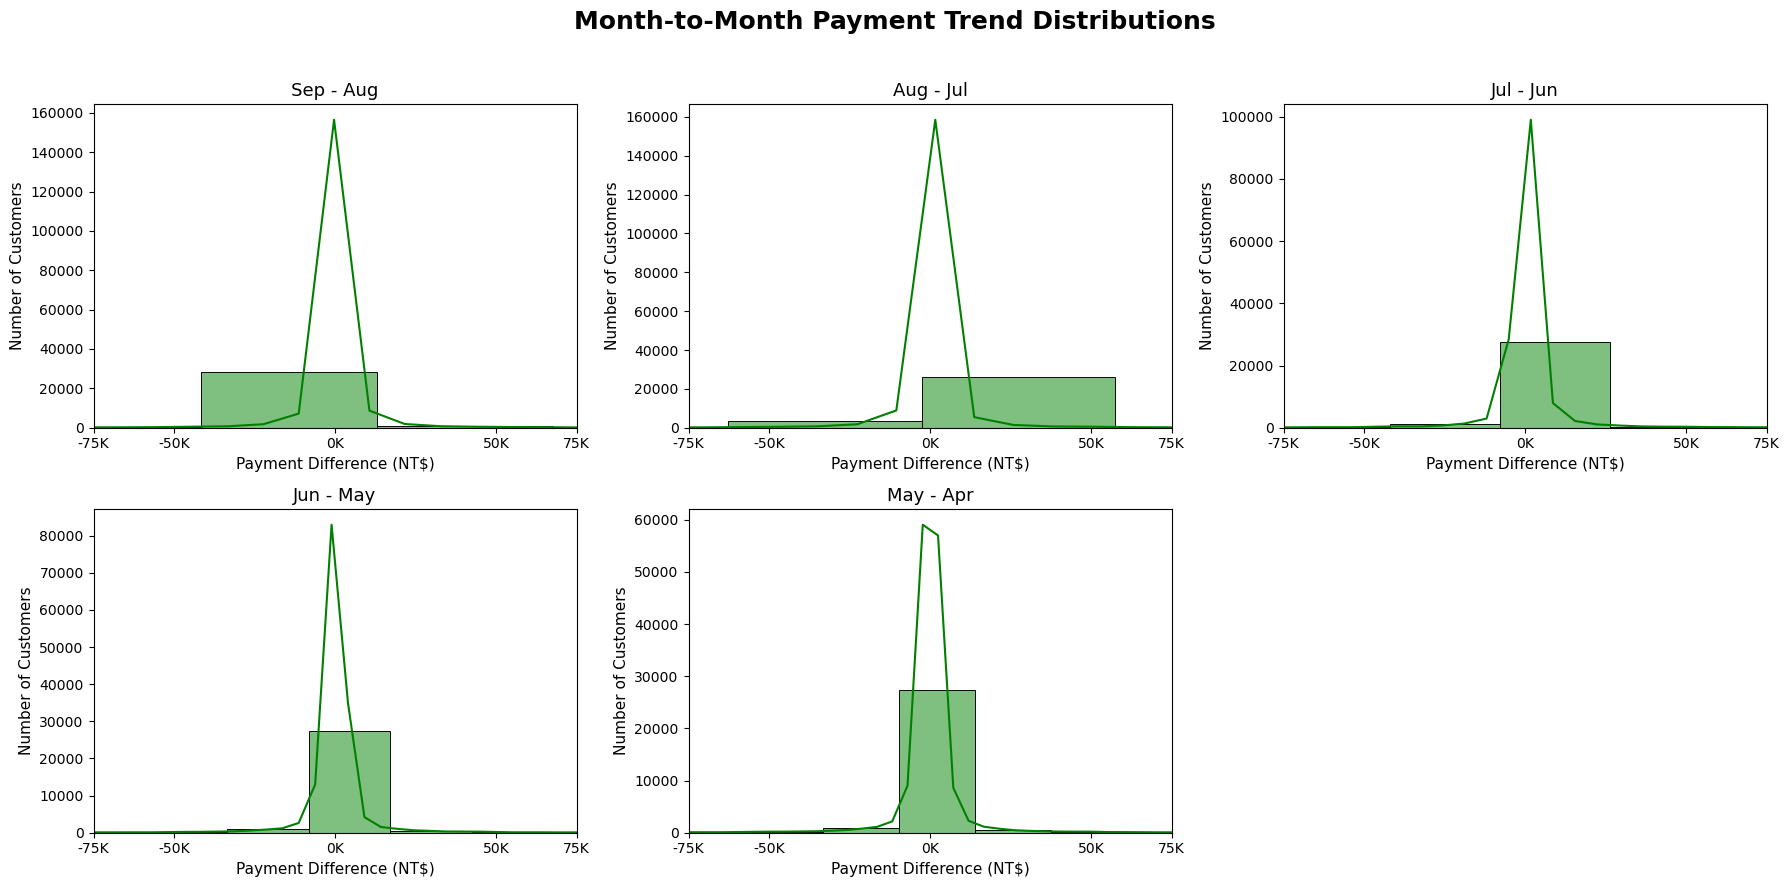

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Month-to-month payment trend columns
trend_cols = [f"payment_trend_{i}" for i in range(1, 6)]

titles = [
    "Sep - Aug",
    "Aug - Jul",
    "Jul - Jun",
    "Jun - May",
    "May - Apr"
]

# Formatter to display values in thousands (K)
formatter = FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col, title in zip(axes.flatten(), trend_cols, titles):

    sns.histplot(
        data=credit_data,
        x=col,
        bins=40,
        kde=True,
        ax=ax,
        color="green"
    )

    # Common x-axis limits
    ax.set_xlim(-75000, 75000)

    ax.set_xticks([-75000, -50000, 0, 50000, 75000])
    ax.xaxis.set_major_formatter(formatter)

    # ax.tick_params(axis="x", rotation=45)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Payment Difference (NT$)", fontsize=11)
    ax.set_ylabel("Number of Customers", fontsize=11)

# Hide the unused subplot
axes[1, 2].axis("off")

plt.suptitle(
    "Month-to-Month Payment Trend Distributions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

##### Most customers pay approximately the same amount each month.
##### Payment behavior is generally stable rather than changing drastically from month to month.

In [10]:
payment_trend_cols = [f"payment_trend_{i}" for i in range(1, 6)]

credit_data[payment_trend_cols].describe().T[
    ["min", "max", "mean", "std"]
]

,min,max,mean,std
payment_trend_1,-1679893.0,504669.0,-257.583000,24233.328670
payment_trend_2,-845317.0,1562428.0,695.482000,25343.440707
payment_trend_3,-519862.0,846040.0,399.604633,20882.869810
payment_trend_4,-414370.0,601000.0,26.689233,20153.739951
payment_trend_5,-528466.0,414910.0,-416.114933,21571.339876


In [11]:
payment_trend_cols = [f"payment_trend_{i}" for i in range(1, 6)]

credit_data["avg_monthly_payment_change"] = credit_data[payment_trend_cols].mean(axis=1)

credit_data["payment_change_std"] = credit_data[payment_trend_cols].std(axis=1)

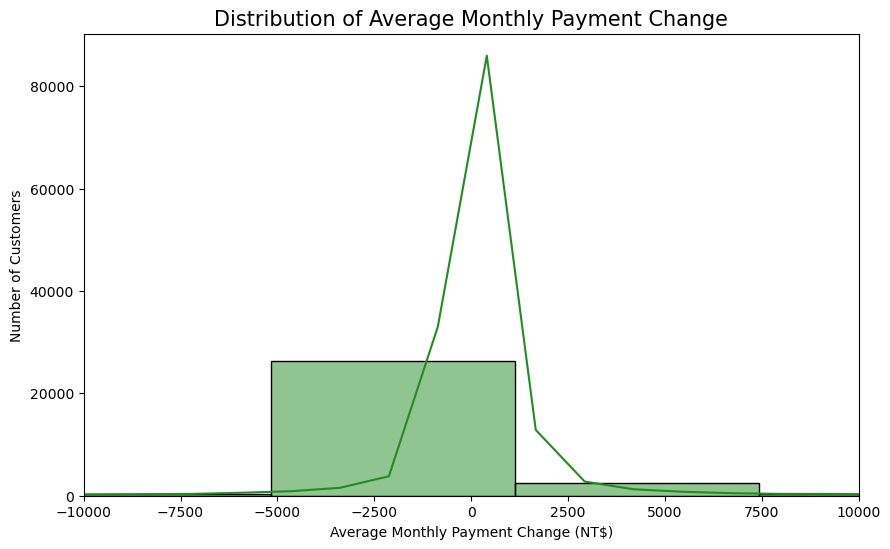

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=credit_data,
    x="avg_monthly_payment_change",
    bins=40,
    kde=True,
    color="forestgreen"
)

ax.set_xlim(-10000, 10000)

plt.title("Distribution of Average Monthly Payment Change", fontsize=15)
plt.xlabel("Average Monthly Payment Change (NT$)")
plt.ylabel("Number of Customers")

plt.show()

In [13]:
credit_data.head()

,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,target,age_group,average_bill,credit_limit_group,credit_utilization,average_payment,avg_payment_ratio,bill_trend_1,bill_trend_2,bill_trend_3,bill_trend_4,bill_trend_5,payment_trend_1,payment_trend_2,payment_trend_3,payment_trend_4,payment_trend_5,avg_monthly_payment_change,payment_change_std
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,20s,1284.000000,≤50K,0.064200,114.833333,0.074038,811,2413,689,0,0,-689,689,0,0,0,0.0,487.196572
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,20s,2846.166667,100K–200K,0.023718,833.333333,0.311916,957,-957,-590,-183,194,-1000,0,0,1000,-2000,-400.0,1140.175425
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,30s,16942.166667,50K–100K,0.188246,1836.333333,0.115141,15212,468,-772,-617,-601,18,500,0,0,-4000,-696.4,1859.130119
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,30s,38555.666667,≤50K,0.771113,1398.000000,0.036396,-1243,-1058,20977,-645,-588,-19,819,100,31,69,200.0,348.871036
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,50s,18223.166667,≤50K,0.364463,9841.500000,1.246958,2947,-30165,14895,1794,15,-34681,26681,1000,8311,10,264.2,22273.141532


In [14]:
credit_data["max_delay"] = credit_data[
    [
        "pay_1","pay_2","pay_3",
        "pay_4","pay_5","pay_6"
    ]
].max(axis=1)

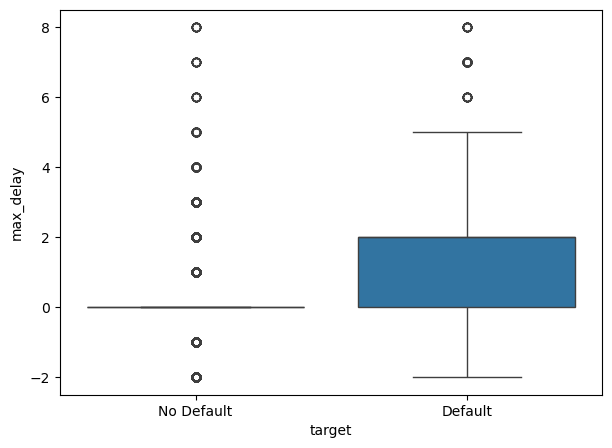

In [15]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=credit_data,
    x="target",
    y="max_delay"
)

plt.xticks([0,1], ["No Default","Default"])

plt.show()

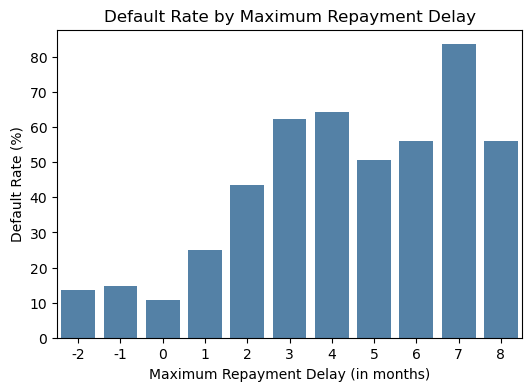

In [16]:
# Calculate default rate (%) for each max_delay
default_rate = (
    credit_data
    .groupby("max_delay")["target"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=default_rate,
    x="max_delay",
    y="target",
    color="steelblue"
)

plt.title("Default Rate by Maximum Repayment Delay")
plt.xlabel("Maximum Repayment Delay (in months)")
plt.ylabel("Default Rate (%)")

plt.show()

In [17]:
#remove unnecessary variables

cols_to_drop = [
    "age_group",
    "credit_limit_group",
    "avg_payment_ratio",
    # "bill_trend",
    "payment_trend_1",
    "payment_trend_2",
    "payment_trend_3",
    "payment_trend_4",
    "payment_trend_5"
]

credit_data.drop(columns=cols_to_drop, inplace=True)

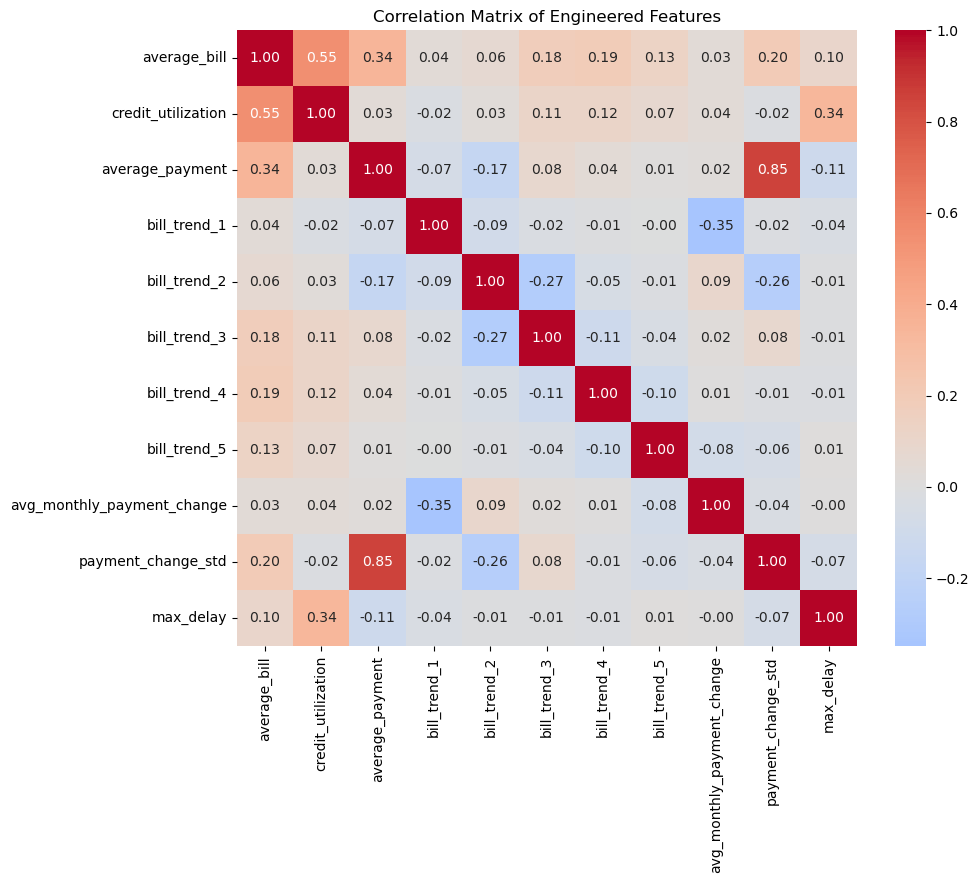

In [18]:
engineered_cols = [
    "average_bill",
    "credit_utilization",
    "average_payment",
    "bill_trend_1",
    "bill_trend_2",
    "bill_trend_3",
    "bill_trend_4",
    "bill_trend_5",
    "avg_monthly_payment_change",
    "payment_change_std",
    "max_delay"
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    credit_data[engineered_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of Engineered Features")
plt.show()

### Split features and target

In [19]:
X = credit_data.drop("target", axis=1)
y = credit_data["target"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTraining target distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (24000, 34)
Testing set shape : (6000, 34)

Training target distribution
target
0    77.879167
1    22.120833
Name: proportion, dtype: float64

Testing target distribution
target
0    77.883333
1    22.116667
Name: proportion, dtype: float64


In [22]:
X_train.to_csv(r"C:\Users\8341s\Documents\ML Specialization\Model Development\CardSecure\data\processed\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\8341s\Documents\ML Specialization\Model Development\CardSecure\data\processed\X_test.csv", index=False)

y_train.to_csv(r"C:\Users\8341s\Documents\ML Specialization\Model Development\CardSecure\data\processed\y_train.csv", index=False)
y_test.to_csv(r"C:\Users\8341s\Documents\ML Specialization\Model Development\CardSecure\data\processed\y_test.csv", index=False)

### Feature Scaling - Standardization

In [23]:
numeric_cols = [
    "limit_bal",
    "age",

    "bill_amt1", "bill_amt2", "bill_amt3",
    "bill_amt4", "bill_amt5", "bill_amt6",

    "pay_amt1", "pay_amt2", "pay_amt3",
    "pay_amt4", "pay_amt5", "pay_amt6",

    "average_bill",
    "credit_utilization",
    "average_payment",

    "bill_trend_1",
    "bill_trend_2",
    "bill_trend_3",
    "bill_trend_4",
    "bill_trend_5",

    "avg_monthly_payment_change",
    "payment_change_std"
]

categorical_cols = [
    "sex",
    "education",
    "marriage",

    "pay_1",
    "pay_2",
    "pay_3",
    "pay_4",
    "pay_5",
    "pay_6",

    "max_delay"
]

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

### VIF - Variance Inflation Factor

VIF = 1/(1 - R^2)

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_train_scaled.values, i)
        for i in range(X_train_scaled.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

C:\Users\8341s\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
17,pay_amt1,inf
25,average_payment,inf
23,average_bill,inf
22,pay_amt6,inf
21,pay_amt5,inf
20,pay_amt4,inf
19,pay_amt3,inf
18,pay_amt2,inf
16,bill_amt6,inf
15,bill_amt5,inf


The correlation heatmap measures pairwise correlations between variables, whereas VIF measures how well one variable can be explained by all the other variables collectively. Hence, low pairwise correlations do not necessarily imply a low VIF.

In this dataset, engineered features such as average_bill and average_payment are exact linear combinations of the monthly bill and payment variables. Although their pairwise correlations with individual monthly variables are only moderate, they can be perfectly explained by the combined monthly variables, resulting in an infinite VIF.

In [26]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDefault rate in training set:")
print(y_train.mean())

print("\nDefault rate in test set:")
print(y_test.mean())

X_train: (24000, 34)
X_test: (6000, 34)
y_train: (24000,)
y_test: (6000,)

Default rate in training set:
0.22120833333333334

Default rate in test set:
0.22116666666666668


In [28]:
credit_data.columns

Index(['limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_1', 'pay_2',
       'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2',
       'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1',
       'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'target',
       'average_bill', 'credit_utilization', 'average_payment', 'bill_trend_1',
       'bill_trend_2', 'bill_trend_3', 'bill_trend_4', 'bill_trend_5',
       'avg_monthly_payment_change', 'payment_change_std', 'max_delay'],
      dtype='object')

#### Creating two feature versions and comparing them

In [29]:
raw_features = [
    'limit_bal',
    'sex',
    'education',
    'marriage',
    'age',
    
    'pay_1',
    'pay_2',
    'pay_3',
    'pay_4',
    'pay_5',
    'pay_6',
    
    'bill_amt1',
    'bill_amt2',
    'bill_amt3',
    'bill_amt4',
    'bill_amt5',
    'bill_amt6',
    
    'pay_amt1',
    'pay_amt2',
    'pay_amt3',
    'pay_amt4',
    'pay_amt5',
    'pay_amt6'
]

X_A = credit_data[raw_features]
y = credit_data['target']

print("Model A features:", X_A.shape)
print(X_A.columns)

Model A features: (30000, 23)
Index(['limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_1', 'pay_2',
       'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2',
       'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1',
       'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6'],
      dtype='object')


In [30]:
engineered_features = [
    'limit_bal',
    'sex',
    'education',
    'marriage',
    'age',
    
    'pay_1',
    'pay_2',
    'pay_3',
    'pay_4',
    'pay_5',
    'pay_6',
    
    'average_bill',
    'credit_utilization',
    'average_payment',
    'bill_trend_1',
    'bill_trend_2',
    'bill_trend_3',
    'bill_trend_4',
    'bill_trend_5',
    'avg_monthly_payment_change',
    'payment_change_std',
    'max_delay'
]

X_B = credit_data[engineered_features]

print("Model B features:", X_B.shape)
print(X_B.columns)

Model B features: (30000, 22)
Index(['limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_1', 'pay_2',
       'pay_3', 'pay_4', 'pay_5', 'pay_6', 'average_bill',
       'credit_utilization', 'average_payment', 'bill_trend_1', 'bill_trend_2',
       'bill_trend_3', 'bill_trend_4', 'bill_trend_5',
       'avg_monthly_payment_change', 'payment_change_std', 'max_delay'],
      dtype='object')


In [31]:
from sklearn.model_selection import train_test_split

X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
X_B_train = X_B.loc[X_A_train.index]
X_B_test = X_B.loc[X_A_test.index]

y_B_train = y.loc[X_A_train.index]
y_B_test = y.loc[X_A_test.index]

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_A = pd.DataFrame()

vif_A["Feature"] = X_A_train.columns

vif_A["VIF"] = [
    variance_inflation_factor(
        X_A_train.values,
        i
    )
    for i in range(X_A_train.shape[1])
]

vif_A.sort_values("VIF", ascending=False)

,Feature,VIF
12,bill_amt2,40.337384
13,bill_amt3,36.340953
15,bill_amt5,34.814621
14,bill_amt4,30.141180
16,bill_amt6,21.157956
11,bill_amt1,20.410857
4,age,11.163508
1,sex,9.172770
2,education,7.395163
3,marriage,6.388384


In [38]:
vif_B = pd.DataFrame()

vif_B["Feature"] = X_B_train.columns

vif_B["VIF"] = [
    variance_inflation_factor(
        X_B_train.values,
        i
    )
    for i in range(X_B_train.shape[1])
]

vif_B.sort_values("VIF", ascending=False)

,Feature,VIF
4,age,12.124463
1,sex,9.333220
2,education,7.539609
3,marriage,7.005626
12,credit_utilization,6.108586
0,limit_bal,5.665313
13,average_payment,4.935416
9,pay_5,4.876976
8,pay_4,4.383880
11,average_bill,4.276523


### Model Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler_A = StandardScaler()

X_A_train_scaled = scaler_A.fit_transform(X_A_train)
X_A_test_scaled = scaler_A.transform(X_A_test)

In [35]:
scaler_B = StandardScaler()

X_B_train_scaled = scaler_B.fit_transform(X_B_train)
X_B_test_scaled = scaler_B.transform(X_B_test)

### Model Training

In [39]:
from sklearn.linear_model import LogisticRegression

model_A = LogisticRegression(max_iter=1000)
model_A.fit(X_A_train_scaled, y_A_train)

model_B = LogisticRegression(max_iter=1000)
model_B.fit(X_B_train_scaled, y_B_train)

LogisticRegression(max_iter=1000)

In [41]:
y_A_pred = model_A.predict(X_A_test_scaled)
y_A_prob = model_A.predict_proba(X_A_test_scaled)[:, 1]

y_B_pred = model_B.predict(X_B_test_scaled)
y_B_prob = model_B.predict_proba(X_B_test_scaled)[:, 1]

In [44]:
print("y_A_pred:")
print(y_A_pred)

print("\ny_A_prob:")
print(y_A_prob)

print("\ny_B_pred:")
print(y_B_pred)

print("\ny_B_prob:")
print(y_B_prob)

y_A_pred:
[0 0 0 ... 0 0 0]

y_A_prob:
[0.10819763 0.1182159  0.21970438 ... 0.15554503 0.11864918 0.04265227]

y_B_pred:
[0 0 0 ... 0 0 0]

y_B_prob:
[0.12776905 0.09403053 0.1766628  ... 0.18061138 0.11424017 0.04818867]


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("========== MODEL A: RAW FEATURES ==========")

print("Accuracy :", accuracy_score(y_A_test, y_A_pred))
print("Precision:", precision_score(y_A_test, y_A_pred))
print("Recall   :", recall_score(y_A_test, y_A_pred))
print("F1 Score :", f1_score(y_A_test, y_A_pred))
print("ROC-AUC  :", roc_auc_score(y_A_test, y_A_prob))


print("\n========== MODEL B: ENGINEERED FEATURES ==========")

print("Accuracy :", accuracy_score(y_B_test, y_B_pred))
print("Precision:", precision_score(y_B_test, y_B_pred))
print("Recall   :", recall_score(y_B_test, y_B_pred))
print("F1 Score :", f1_score(y_B_test, y_B_pred))
print("ROC-AUC  :", roc_auc_score(y_B_test, y_B_prob))

========== MODEL A: RAW FEATURES ==========
Accuracy : 0.8083333333333333
Precision: 0.6903225806451613
Recall   : 0.24189902034664656
F1 Score : 0.35825892857142855
ROC-AUC  : 0.707924808472601

========== MODEL B: ENGINEERED FEATURES ==========
Accuracy : 0.8083333333333333
Precision: 0.698876404494382
Recall   : 0.2343632253202713
F1 Score : 0.3510158013544018
ROC-AUC  : 0.7268236406259498


In [51]:
from sklearn.metrics import roc_auc_score

auc_A = roc_auc_score(y_A_test, y_A_prob)
auc_B = roc_auc_score(y_B_test, y_B_prob)

ar_A = 2 * auc_A - 1
ar_B = 2 * auc_B - 1

print("Model A")
print("ROC-AUC:", auc_A)
print("AR     :", ar_A)

print("\nModel B")
print("ROC-AUC:", auc_B)
print("AR     :", ar_B)

Model A
ROC-AUC: 0.707924808472601
AR     : 0.41584961694520195

Model B
ROC-AUC: 0.7268236406259498
AR     : 0.4536472812518997


In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Model A Confusion Matrix")
cm_A = confusion_matrix(y_A_test, y_A_pred)
print(cm_A)

print("\nModel B Confusion Matrix")
cm_B = confusion_matrix(y_B_test, y_B_pred)
print(cm_B)

Model A Confusion Matrix
[[4529  144]
 [1006  321]]

Model B Confusion Matrix
[[4539  134]
 [1016  311]]


#### Model B makes fewer false-positive predictions, that's why Model B has slightly higher precision.
#### But Model B also catches fewer actual defaults, that's why Model B's recall is slightly lower.

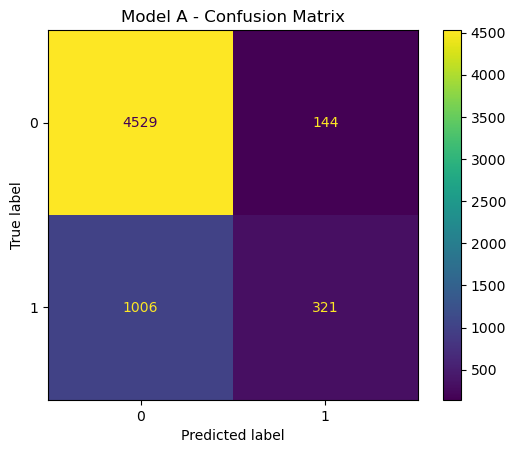

In [48]:
fig, ax = plt.subplots()

ConfusionMatrixDisplay(
    confusion_matrix=cm_A
).plot(ax=ax)

ax.set_title("Model A - Confusion Matrix")
plt.show()

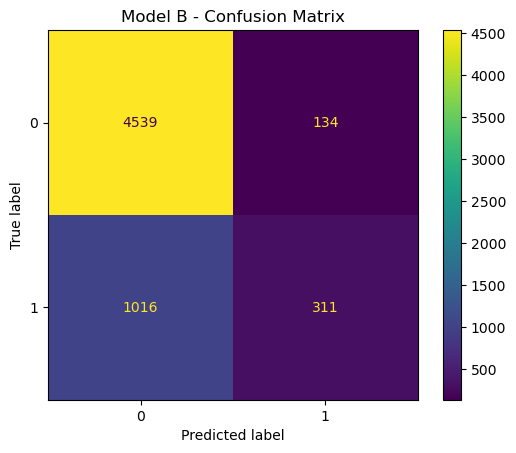

In [50]:
fig, ax = plt.subplots()

ConfusionMatrixDisplay(
    confusion_matrix=cm_B
).plot(ax=ax)

ax.set_title("Model B - Confusion Matrix")
plt.show()

## Kolmogorov-Smirnov (KS)

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def calculate_ks_data(y_true, y_prob):
    df = pd.DataFrame({
        "actual": np.asarray(y_true),
        "probability": np.asarray(y_prob)
    })

    # Highest-risk customers first
    df = df.sort_values("probability", ascending=False).reset_index(drop=True)

    # Cumulative bads and goods
    df["cum_bad"] = (df["actual"] == 1).cumsum() / (df["actual"] == 1).sum()
    df["cum_good"] = (df["actual"] == 0).cumsum() / (df["actual"] == 0).sum()

    # KS at each cutoff
    df["ks"] = df["cum_bad"] - df["cum_good"]

    # Maximum absolute KS
    max_ks_idx = df["ks"].abs().idxmax()

    return df, max_ks_idx

In [53]:
ks_A_data, ks_A_idx = calculate_ks_data(y_A_test, y_A_prob)
ks_B_data, ks_B_idx = calculate_ks_data(y_B_test, y_B_prob)

ks_A = abs(ks_A_data.loc[ks_A_idx, "ks"])
ks_B = abs(ks_B_data.loc[ks_B_idx, "ks"])

print("Model A KS:", ks_A)
print("Model B KS:", ks_B)

Model A KS: 0.36381634720840966
Model B KS: 0.38605879532745235


In [61]:
ks_A_data["rank_pct"] = np.arange(1, len(ks_A_data) + 1) / len(ks_A_data)
ks_B_data["rank_pct"] = np.arange(1, len(ks_B_data) + 1) / len(ks_B_data)

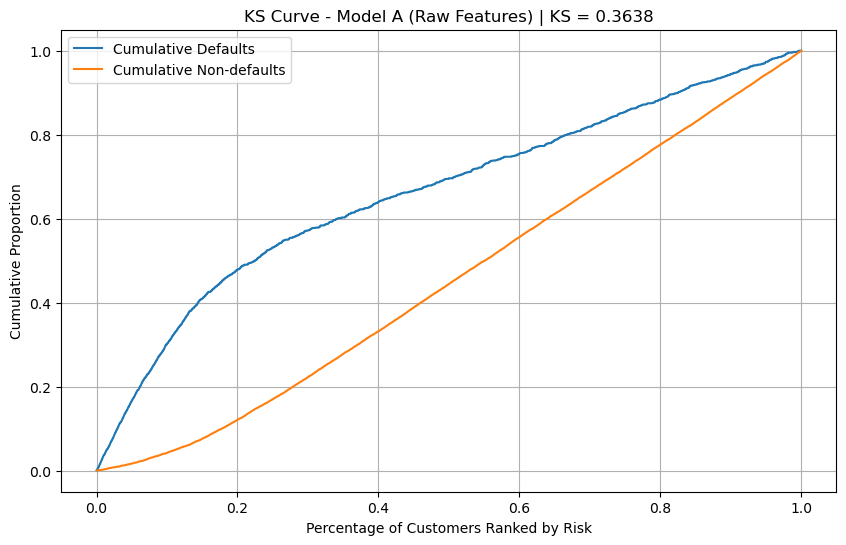

In [62]:
plt.figure(figsize=(10, 6))

plt.plot(
    ks_A_data["rank_pct"],
    ks_A_data["cum_bad"],
    label="Cumulative Defaults"
)

plt.plot(
    ks_A_data["rank_pct"],
    ks_A_data["cum_good"],
    label="Cumulative Non-defaults"
)

plt.xlabel("Percentage of Customers Ranked by Risk")
plt.ylabel("Cumulative Proportion")
plt.title(f"KS Curve - Model A (Raw Features) | KS = {ks_A:.4f}")
plt.legend()
plt.grid(True)
plt.show()

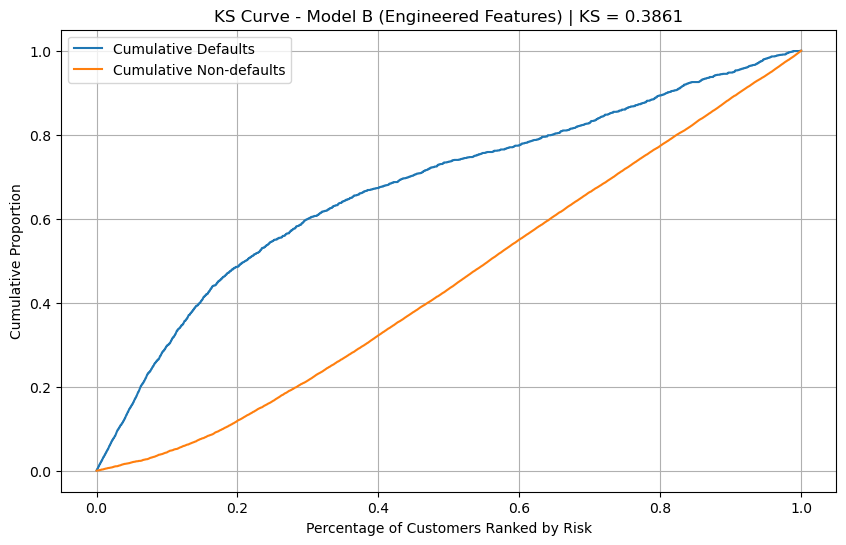

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(
    ks_B_data["rank_pct"],
    ks_B_data["cum_bad"],
    label="Cumulative Defaults"
)

plt.plot(
    ks_B_data["rank_pct"],
    ks_B_data["cum_good"],
    label="Cumulative Non-defaults"
)

plt.xlabel("Percentage of Customers Ranked by Risk")
plt.ylabel("Cumulative Proportion")
plt.title(f"KS Curve - Model B (Engineered Features) | KS = {ks_B:.4f}")
plt.legend()
plt.grid(True)
plt.show()

 ## Accuracy Ratio (AR)

In [64]:
from sklearn.metrics import roc_auc_score

auc_A = roc_auc_score(y_A_test, y_A_prob)
auc_B = roc_auc_score(y_B_test, y_B_prob)

ar_A = 2 * auc_A - 1
ar_B = 2 * auc_B - 1

print("Model A AR:", ar_A)
print("Model B AR:", ar_B)

Model A AR: 0.41584961694520195
Model B AR: 0.4536472812518997


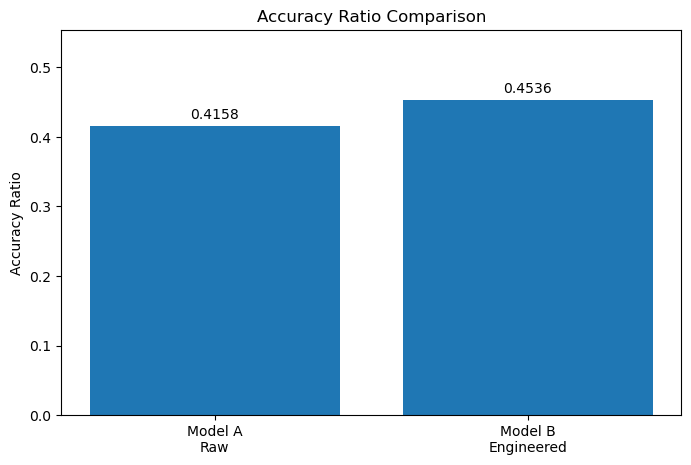

In [65]:
models = ["Model A\nRaw", "Model B\nEngineered"]
ar_values = [ar_A, ar_B]

plt.figure(figsize=(8, 5))

plt.bar(models, ar_values)

plt.ylabel("Accuracy Ratio")
plt.title("Accuracy Ratio Comparison")

plt.ylim(0, max(ar_values) + 0.1)

for i, value in enumerate(ar_values):
    plt.text(
        i,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.show()

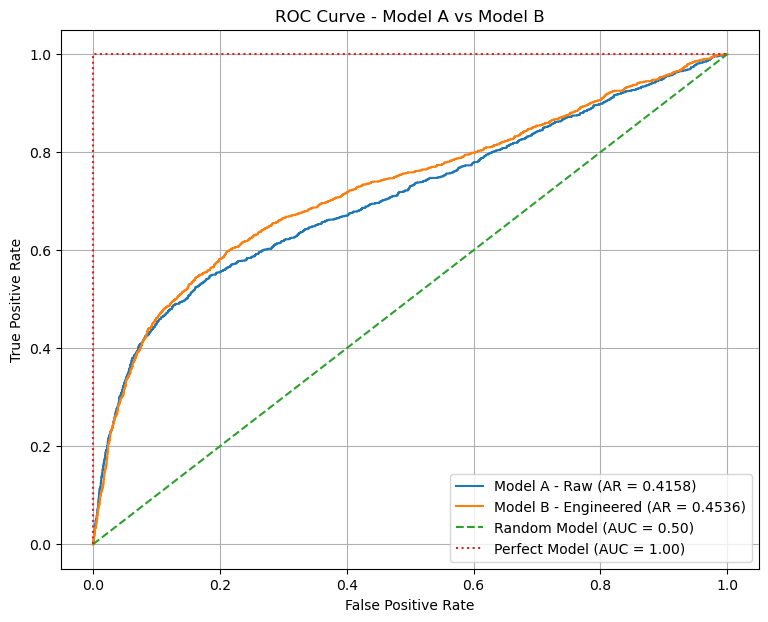

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC values
fpr_A, tpr_A, _ = roc_curve(y_A_test, y_A_prob)
fpr_B, tpr_B, _ = roc_curve(y_B_test, y_B_prob)

# AUC
auc_A = roc_auc_score(y_A_test, y_A_prob)
auc_B = roc_auc_score(y_B_test, y_B_prob)

plt.figure(figsize=(9, 7))

# Model curves
plt.plot(
    fpr_A,
    tpr_A,
    label=f"Model A - Raw (AR = {ar_A:.4f})"
)

plt.plot(
    fpr_B,
    tpr_B,
    label=f"Model B - Engineered (AR = {ar_B:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model (AUC = 0.50)"
)

# Perfect classifier
plt.plot(
    [0, 0, 1],
    [0, 1, 1],
    linestyle=":",
    label="Perfect Model (AUC = 1.00)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model A vs Model B")

plt.legend()
plt.grid(True)
plt.show()